# Capítulo 13 — Aprendizaje por refuerzo

Este *notebook* acompaña al capítulo 13 de *IA para Estudiantes de Ciencias*. Contiene dos bloques completos y autocontenidos:

1. **Q-learning** tabular sobre un problema de **control de temperatura de un reactor**, formalizado como un entorno con la interfaz clásica de OpenAI Gym (`reset` / `step`).
2. **Optimización bayesiana** para maximizar el **rendimiento de una reacción de síntesis** en función de la temperatura, la presión y el tiempo de reacción.

Ambos bloques materializan las ideas de la sección 13.1 (marco agente-entorno y ecuación de Bellman), la sección 13.2 (Q-learning) y la sección 13.4 (optimización bayesiana de experimentos).

**Dependencias.** El bloque de Q-learning solo necesita `numpy` y `matplotlib`. El de optimización bayesiana usa `scikit-optimize`:

```
pip install scikit-optimize
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla global para reproducibilidad
np.random.seed(42)

# Estilo de figuras coherente con el resto del libro
plt.rcParams.update({
    "figure.figsize": (6.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

---
## Parte 1 — Q-learning: control de temperatura de un reactor

Recordemos el marco de la sección 13.1. Un agente interacciona con un entorno: en cada paso $t$ observa un estado $s_t$, ejecuta una acción $a_t$ y recibe una recompensa $r_t$ junto con el nuevo estado $s_{t+1}$. El objetivo es aprender una política $\pi$ que maximice el retorno descontado $G_t = \sum_{k\ge 0}\gamma^k r_{t+k+1}$.

Planteamos un problema de control sencillo pero representativo: mantener la temperatura de un reactor dentro de una **ventana objetivo**. El agente dispone de tres acciones —enfriar, mantener o calentar— y debe aprender, sin conocer la dinámica del sistema, a llevar la temperatura al valor deseado y sostenerla allí pese a las perturbaciones térmicas del proceso.

### 1.1 El entorno

Implementamos el reactor como un entorno con la **interfaz clásica de Gym**: `reset()` devuelve la observación inicial y `step(a)` devuelve la tupla `(observación, recompensa, terminado, info)`. Para poder aplicar Q-learning tabular, discretizamos la temperatura en una rejilla de celdas; el estado observado es el índice de la celda.

La recompensa premia con $+1$ cada paso que el reactor pasa dentro de la ventana objetivo y penaliza de forma proporcional al error de temperatura cuando está fuera de ella. Así, la estrategia óptima consiste en alcanzar la ventana cuanto antes y permanecer en ella.

In [2]:
class EntornoReactor:
    """Entorno simplificado tipo Gym para el control de temperatura de un reactor.

    Interfaz clasica de Gym:
        reset()  -> observacion
        step(a)  -> (observacion, recompensa, terminado, info)

    Estado observado : indice de la celda de temperatura (entero).
    Acciones         : 0 = enfriar, 1 = mantener, 2 = calentar.

    Con Gymnasium la interfaz cambia ligeramente: reset() -> (obs, info)
    y step() -> (obs, recompensa, terminated, truncated, info). Aqui usamos
    la version clasica por simplicidad.
    """
    def __init__(self, t_min=20.0, t_max=200.0, n_celdas=37,
                 t_objetivo=150.0, tolerancia=5.0, max_pasos=100, semilla=None):
        self.t_min, self.t_max = t_min, t_max
        self.n_celdas   = n_celdas
        self.t_objetivo = t_objetivo
        self.tolerancia = tolerancia
        self.max_pasos  = max_pasos
        self.delta      = (t_max - t_min) / (n_celdas - 1)  # paso termico por accion
        self.n_acciones = 3
        self.rng = np.random.default_rng(semilla)

    def _discretizar(self, t):
        idx = int(round((t - self.t_min) / self.delta))
        return int(np.clip(idx, 0, self.n_celdas - 1))

    def reset(self):
        # temperatura inicial aleatoria en todo el rango
        self.temperatura = self.rng.uniform(self.t_min, self.t_max)
        self.paso = 0
        return self._discretizar(self.temperatura)

    def step(self, accion):
        if accion == 0:      self.temperatura -= self.delta   # enfriar
        elif accion == 2:    self.temperatura += self.delta   # calentar
        # accion == 1: mantener
        self.temperatura += self.rng.normal(0, 0.3)           # ruido del proceso
        self.temperatura  = float(np.clip(self.temperatura, self.t_min, self.t_max))
        self.paso += 1

        error      = abs(self.temperatura - self.t_objetivo)
        en_ventana = error <= self.tolerancia
        if en_ventana:
            recompensa = 1.0
        else:
            recompensa = -error / (self.t_max - self.t_min)   # penalizacion normalizada

        terminado = self.paso >= self.max_pasos
        info = {"temperatura": self.temperatura, "en_ventana": en_ventana}
        return self._discretizar(self.temperatura), recompensa, terminado, info


entorno = EntornoReactor(semilla=42)
print(f"Numero de estados (celdas): {entorno.n_celdas}")
print(f"Numero de acciones        : {entorno.n_acciones}")
print(f"Temperatura objetivo      : {entorno.t_objetivo} +/- {entorno.tolerancia} C")
print(f"Celda objetivo            : indice {entorno._discretizar(entorno.t_objetivo)}")

Numero de estados (celdas): 37
Numero de acciones        : 3
Temperatura objetivo      : 150.0 +/- 5.0 C
Celda objetivo            : indice 26


### 1.2 El algoritmo de Q-learning tabular

Q-learning mantiene una tabla $Q(s,a)$ con un valor para cada par estado-acción y la actualiza tras cada transición observada, siguiendo la regla de la ecuación (13.5) del capítulo:

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha\Bigl[r_t + \gamma\,\max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\Bigr].$$

El término entre corchetes es el **error de diferencia temporal**. La exploración se controla con una estrategia $\varepsilon$-*greedy* cuyo $\varepsilon$ decae linealmente: al principio el agente explora mucho y, a medida que aprende, explota cada vez más su conocimiento.

In [3]:
def entrenar_qlearning(entorno, n_episodios=2000, alpha=0.1, gamma=0.95,
                       eps_inicio=1.0, eps_fin=0.05, semilla=0):
    """Q-learning tabular con exploracion epsilon-greedy decreciente.

    Devuelve la tabla Q aprendida y el retorno obtenido en cada episodio.
    """
    rng = np.random.default_rng(semilla)
    Q   = np.zeros((entorno.n_celdas, entorno.n_acciones))
    retornos = np.zeros(n_episodios)

    for episodio in range(n_episodios):
        # epsilon decae linealmente de eps_inicio a eps_fin
        eps = eps_fin + (eps_inicio - eps_fin) * (1 - episodio / n_episodios)
        estado    = entorno.reset()
        retorno   = 0.0
        terminado = False

        while not terminado:
            # seleccion epsilon-greedy
            if rng.random() < eps:
                accion = int(rng.integers(entorno.n_acciones))
            else:
                accion = int(np.argmax(Q[estado]))

            estado_sig, recompensa, terminado, _ = entorno.step(accion)

            # actualizacion de Q-learning (error de diferencia temporal)
            objetivo = recompensa + gamma * np.max(Q[estado_sig]) * (not terminado)
            Q[estado, accion] += alpha * (objetivo - Q[estado, accion])

            estado   = estado_sig
            retorno += recompensa

        retornos[episodio] = retorno

    return Q, retornos


Q, retornos = entrenar_qlearning(entorno, n_episodios=2000,
                                 alpha=0.1, gamma=0.95, semilla=0)

print(f"Retorno medio (primeros 50 episodios): {retornos[:50].mean():7.2f}")
print(f"Retorno medio (ultimos  50 episodios): {retornos[-50:].mean():7.2f}")

Retorno medio (primeros 50 episodios):  -26.70
Retorno medio (ultimos  50 episodios):   80.85


### 1.3 Curva de aprendizaje

El retorno por episodio es muy ruidoso porque la temperatura inicial es aleatoria y la exploración introduce variabilidad. Para ver la tendencia, representamos una media móvil del retorno a lo largo del entrenamiento.

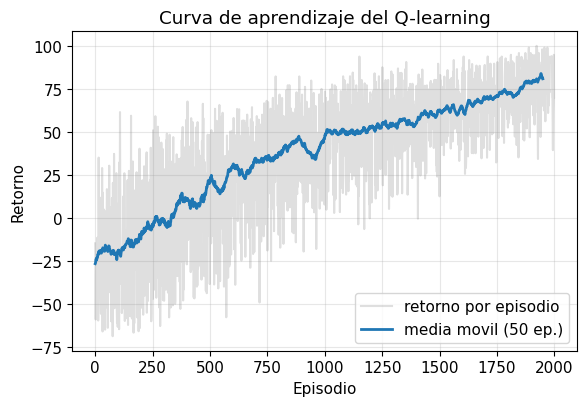

In [4]:
def media_movil(x, ventana=50):
    return np.convolve(x, np.ones(ventana) / ventana, mode="valid")

suavizado = media_movil(retornos, ventana=50)

fig, ax = plt.subplots()
ax.plot(retornos, alpha=0.25, color="gray", label="retorno por episodio")
ax.plot(range(len(suavizado)), suavizado, color="C0", lw=2,
        label="media movil (50 ep.)")
ax.set_xlabel("Episodio")
ax.set_ylabel("Retorno")
ax.set_title("Curva de aprendizaje del Q-learning")
ax.legend()
fig.tight_layout()
plt.show()

La curva crece con rapidez durante los primeros centenares de episodios y luego se estabiliza: el agente ha aprendido a llevar el reactor a la ventana objetivo y mantenerlo en ella casi todo el episodio (el retorno máximo posible se acerca a la longitud del episodio, 100).

### 1.4 La política aprendida

De la tabla $Q$ se deriva la política óptima eligiendo en cada estado la acción de mayor valor: $\pi(s) = \arg\max_a Q(s,a)$. Como el estado es la temperatura discretizada, podemos visualizar la política completa: qué decide hacer el agente en cada nivel de temperatura.

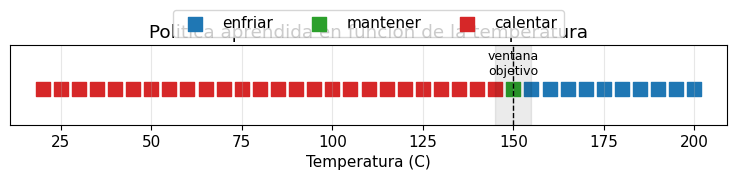

In [5]:
politica = np.argmax(Q, axis=1)
temperaturas_celda = entorno.t_min + np.arange(entorno.n_celdas) * entorno.delta
nombres_accion = {0: "enfriar", 1: "mantener", 2: "calentar"}
colores_accion = {0: "C0", 1: "C2", 2: "C3"}

fig, ax = plt.subplots(figsize=(7.5, 2.6))
for a in (0, 1, 2):
    mascara = politica == a
    ax.scatter(temperaturas_celda[mascara], np.zeros(mascara.sum()),
               s=90, marker="s", color=colores_accion[a], label=nombres_accion[a])
ax.axvline(entorno.t_objetivo, color="black", ls="--", lw=1)
ax.axvspan(entorno.t_objetivo - entorno.tolerancia,
           entorno.t_objetivo + entorno.tolerancia, color="black", alpha=0.08)
ax.text(entorno.t_objetivo, 0.04, "ventana\nobjetivo", ha="center", fontsize=9)
ax.set_yticks([])
ax.set_xlabel("Temperatura (C)")
ax.set_title("Politica aprendida en funcion de la temperatura")
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.55))
ax.set_ylim(-0.1, 0.12)
fig.tight_layout()
plt.show()

La política aprendida es exactamente la que dicta el sentido común físico: **calentar** cuando el reactor está por debajo de la ventana, **enfriar** cuando está por encima, y **mantener** dentro de la ventana objetivo. El agente ha descubierto esta regla por sí solo, únicamente a partir de la señal de recompensa, sin conocer en ningún momento la dinámica del entorno.

### 1.5 Los valores $Q$ y una trayectoria con la política aprendida

Conviene mirar los propios valores $Q(s,a)$: codifican el retorno esperado de cada acción en cada estado y, por tanto, una noción de *cercanía* a la región de alta recompensa. Después simulamos un episodio completo siguiendo la política aprendida (sin exploración) para comprobar que el control funciona.

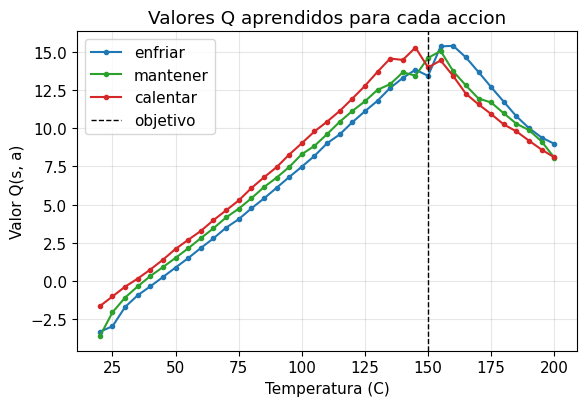

In [6]:
fig, ax = plt.subplots()
for a in (0, 1, 2):
    ax.plot(temperaturas_celda, Q[:, a], marker="o", ms=3,
            color=colores_accion[a], label=nombres_accion[a])
ax.axvline(entorno.t_objetivo, color="black", ls="--", lw=1, label="objetivo")
ax.set_xlabel("Temperatura (C)")
ax.set_ylabel("Valor Q(s, a)")
ax.set_title("Valores Q aprendidos para cada accion")
ax.legend()
fig.tight_layout()
plt.show()

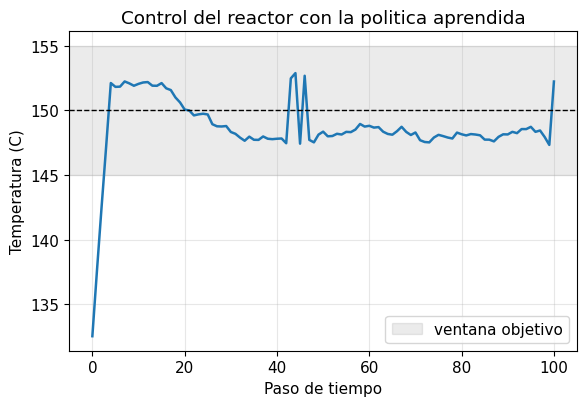

Temperatura inicial: 132.5 C
Pasos dentro de la ventana objetivo: 98 de 101


In [7]:
# Simular un episodio siguiendo la politica greedy (sin exploracion)
entorno_test = EntornoReactor(semilla=7)
estado = entorno_test.reset()
historial_temp = [entorno_test.temperatura]
terminado = False
while not terminado:
    accion = int(np.argmax(Q[estado]))
    estado, _, terminado, info = entorno_test.step(accion)
    historial_temp.append(info["temperatura"])

fig, ax = plt.subplots()
ax.plot(historial_temp, color="C0", lw=1.8)
ax.axhline(entorno.t_objetivo, color="black", ls="--", lw=1)
ax.axhspan(entorno.t_objetivo - entorno.tolerancia,
           entorno.t_objetivo + entorno.tolerancia, color="black", alpha=0.08,
           label="ventana objetivo")
ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Temperatura (C)")
ax.set_title("Control del reactor con la politica aprendida")
ax.legend()
fig.tight_layout()
plt.show()

pasos_en_ventana = sum(abs(t - entorno.t_objetivo) <= entorno.tolerancia
                       for t in historial_temp)
print(f"Temperatura inicial: {historial_temp[0]:.1f} C")
print(f"Pasos dentro de la ventana objetivo: {pasos_en_ventana} de {len(historial_temp)}")

Partiendo de una temperatura inicial cualquiera, el agente conduce el reactor hasta la ventana objetivo en pocos pasos y lo mantiene ahí el resto del episodio, corrigiendo las pequeñas perturbaciones térmicas. El control aprendido es estable.

---
## Parte 2 — Optimización bayesiana: condiciones de una reacción de síntesis

El Q-learning anterior necesita miles de interacciones con el entorno. En un laboratorio eso es inviable: cada *experimento* (una síntesis seguida de su caracterización) puede costar horas o días. Cuando la evaluación de la función objetivo es **cara**, el método de elección es la **optimización bayesiana** (sección 13.4): construye un modelo probabilístico de la función objetivo —un proceso gaussiano— y usa una **función de adquisición** para decidir, en cada paso, qué experimento realizar a continuación, equilibrando exploración y explotación.

Aquí buscamos las condiciones —temperatura, presión y tiempo de reacción— que **maximizan el rendimiento** de una reacción de síntesis. La función de rendimiento simula el experimento real; en la práctica, cada llamada ejecutaría la síntesis y mediría el producto.

### 2.1 El espacio de búsqueda y la función objetivo

Definimos el espacio de diseño con tres variables continuas y una función de rendimiento con un óptimo en $T=150\,$°C, $P=5\,$bar y $t=2\,$h, más un ruido gaussiano que representa la variabilidad experimental. La biblioteca `scikit-optimize` **minimiza**, así que la función que le pasamos devuelve el rendimiento con signo negativo.

In [8]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

# Espacio de busqueda
espacio = [
    Real( 50.0, 200.0, name="temperatura"),     # grados Celsius
    Real(  1.0,  10.0, name="presion"),          # bar
    Real(  0.5,   4.0, name="tiempo_reaccion"),  # horas
]

def rendimiento_reaccion(temperatura, presion, tiempo_reaccion):
    """Rendimiento (%) de una reaccion hipotetica. En la practica, esta
    funcion ejecutaria el experimento o una simulacion costosa.
    Optimo en T=150 C, P=5 bar, t=2 h."""
    rend = (100
            - 0.005 * (temperatura - 150)**2
            - 0.02  * (presion - 5)**2
            - 2.0   * (tiempo_reaccion - 2)**2
            + np.random.normal(0, 1.5))          # ruido experimental
    return float(np.clip(rend, 0, 100))

@use_named_args(espacio)
def objetivo(**params):
    # gp_minimize MINIMIZA: devolvemos el rendimiento negado
    return -rendimiento_reaccion(**params)

### 2.2 El bucle de optimización bayesiana

Ejecutamos la BO con 8 evaluaciones iniciales aleatorias y un presupuesto total de 40 evaluaciones, usando *Expected Improvement* (EI) como función de adquisición. La varianza del ruido se le comunica al modelo mediante el argumento `noise`.

In [9]:
resultado = gp_minimize(
    func             = objetivo,
    dimensions       = espacio,
    n_calls          = 40,        # total de evaluaciones
    n_initial_points = 8,         # evaluaciones iniciales aleatorias
    acq_func         = "EI",      # Expected Improvement
    noise            = 1.5**2,    # varianza del ruido experimental
    random_state     = 42,
)

print(f"Mejor rendimiento encontrado: {-resultado.fun:.2f}%")
print("Condiciones optimas:")
for nombre, valor in zip(["temperatura", "presion", "tiempo"], resultado.x):
    print(f"  {nombre:12s}: {valor:6.2f}")
print(f"Evaluaciones realizadas: {len(resultado.func_vals)}")

Mejor rendimiento encontrado: 99.90%
Condiciones optimas:
  temperatura : 147.63
  presion     :   1.51
  tiempo      :   3.03
Evaluaciones realizadas: 40


La BO recupera condiciones muy próximas al óptimo verdadero ($T\approx 150$, $P\approx 5$, $t\approx 2$) en unas pocas decenas de evaluaciones. Conviene recordar que la presión apenas influye en el rendimiento (su coeficiente es pequeño), así que el modelo no necesita afinarla tanto como la temperatura o el tiempo.

### 2.3 Convergencia y los mejores experimentos

Representamos la curva de convergencia —el mejor rendimiento acumulado frente al número de evaluaciones— y listamos los cinco mejores experimentos hallados.

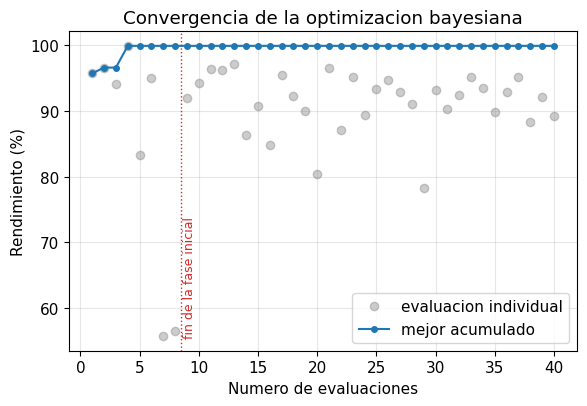

Cinco mejores experimentos:
  1. T=  148 C, P= 1.5 bar, t=3.0 h  ->   99.9%
  2. T=  131 C, P= 9.6 bar, t=1.3 h  ->   97.1%
  3. T=  140 C, P= 5.0 bar, t=0.8 h  ->   96.6%
  4. T=  137 C, P= 1.0 bar, t=0.5 h  ->   96.6%
  5. T=  158 C, P= 1.4 bar, t=0.9 h  ->   96.5%


In [10]:
rendimientos    = -np.array(resultado.func_vals)
mejor_acumulado = np.maximum.accumulate(rendimientos)

fig, ax = plt.subplots()
ax.plot(range(1, len(rendimientos) + 1), rendimientos, "o", alpha=0.4,
        color="gray", label="evaluacion individual")
ax.plot(range(1, len(mejor_acumulado) + 1), mejor_acumulado, "-o", ms=4,
        color="C0", label="mejor acumulado")
ax.axvline(8.5, color="C3", ls=":", lw=1)
ax.text(8.7, ax.get_ylim()[0] + 2, "fin de la fase inicial", color="C3",
        fontsize=9, rotation=90, va="bottom")
ax.set_xlabel("Numero de evaluaciones")
ax.set_ylabel("Rendimiento (%)")
ax.set_title("Convergencia de la optimizacion bayesiana")
ax.legend()
fig.tight_layout()
plt.show()

indices_ordenados = np.argsort(resultado.func_vals)[:5]
print("Cinco mejores experimentos:")
for i, idx in enumerate(indices_ordenados, start=1):
    T, P, t = resultado.x_iters[idx]
    rend = -resultado.func_vals[idx]
    print(f"  {i}. T={T:5.0f} C, P={P:4.1f} bar, t={t:3.1f} h  ->  {rend:5.1f}%")

### 2.4 Dependencia parcial estimada por el proceso gaussiano

`scikit-optimize` permite visualizar la **dependencia parcial** de la función objetivo estimada por el GP: cómo varía el rendimiento previsto con cada variable y con cada par de variables. La diagonal muestra el efecto marginal de cada parámetro; los paneles inferiores, las interacciones. El punto rojo marca el óptimo encontrado.

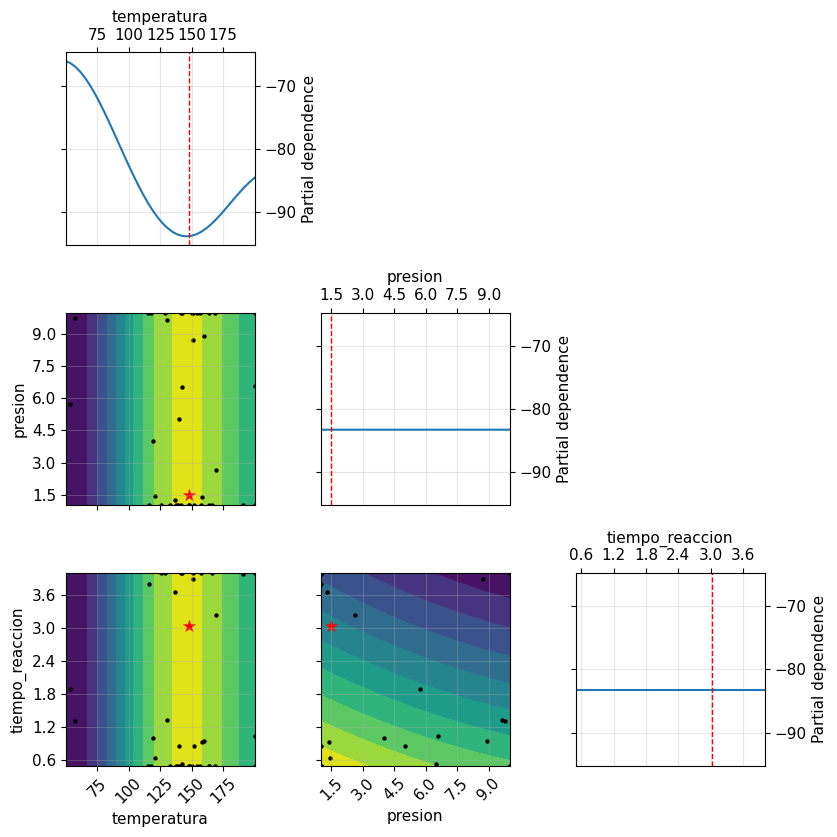

In [11]:
from skopt.plots import plot_objective

plot_objective(resultado, n_samples=40,
               dimensions=["temperatura", "presion", "tiempo_reaccion"])
plt.gcf().set_size_inches(8.5, 8.5)
plt.tight_layout()
plt.show()

Los perfiles marginales reflejan la estructura de la función objetivo: el rendimiento cae claramente al alejarse de la temperatura y el tiempo óptimos, mientras que la dependencia de la presión es muy suave. Es exactamente lo que cabía esperar de los coeficientes de la función, y muestra que el GP ha capturado bien la forma del paisaje a partir de un puñado de experimentos.

### 2.5 ¿Es realmente mejor que la búsqueda aleatoria?

La intuición del capítulo es que la BO aprende de los experimentos previos y por eso encuentra el óptimo con muchas menos evaluaciones que una búsqueda aleatoria. Para comprobarlo con honestidad **promediamos sobre varias semillas** —una sola corrida es demasiado ruidosa para concluir nada—, comparando la curva de convergencia media de la BO con la de la búsqueda aleatoria con el mismo presupuesto.

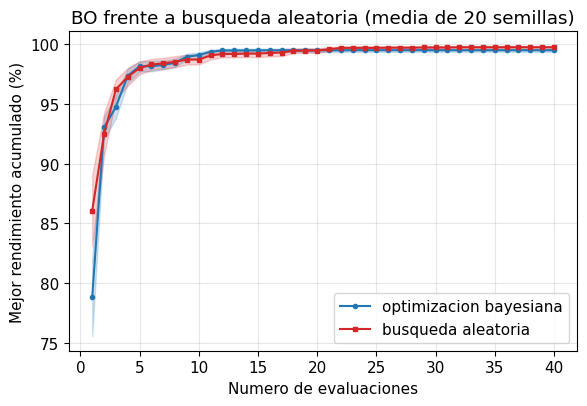

Tras  5 evaluaciones:  BO = 98.17%   aleatoria = 98.04%
Tras 10 evaluaciones:  BO = 99.11%   aleatoria = 98.73%
Tras 20 evaluaciones:  BO = 99.51%   aleatoria = 99.49%
Tras 40 evaluaciones:  BO = 99.52%   aleatoria = 99.77%


In [12]:
import warnings

def busqueda_aleatoria(n_evaluaciones, semilla):
    rng = np.random.default_rng(semilla)
    rendimientos = []
    for _ in range(n_evaluaciones):
        T = rng.uniform( 50, 200)
        P = rng.uniform(  1,  10)
        t = rng.uniform(0.5,   4)
        rendimientos.append(rendimiento_reaccion(T, P, t))
    return np.maximum.accumulate(rendimientos)

N = 40            # presupuesto de evaluaciones
n_semillas = 20

curvas_bo   = np.zeros((n_semillas, N))
curvas_rand = np.zeros((n_semillas, N))

for s in range(n_semillas):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        res = gp_minimize(objetivo, espacio, n_calls=N, n_initial_points=8,
                          acq_func="EI", noise=1.5**2, random_state=s)
    curvas_bo[s]   = np.maximum.accumulate(-np.array(res.func_vals))
    curvas_rand[s] = busqueda_aleatoria(N, semilla=100 + s)

media_bo,   err_bo   = curvas_bo.mean(0),   curvas_bo.std(0)   / np.sqrt(n_semillas)
media_rand, err_rand = curvas_rand.mean(0), curvas_rand.std(0) / np.sqrt(n_semillas)

x = np.arange(1, N + 1)
fig, ax = plt.subplots()
ax.plot(x, media_bo, "-o", ms=3, color="C0", label="optimizacion bayesiana")
ax.fill_between(x, media_bo - err_bo, media_bo + err_bo, color="C0", alpha=0.2)
ax.plot(x, media_rand, "-s", ms=3, color="C3", label="busqueda aleatoria")
ax.fill_between(x, media_rand - err_rand, media_rand + err_rand, color="C3", alpha=0.2)
ax.set_xlabel("Numero de evaluaciones")
ax.set_ylabel("Mejor rendimiento acumulado (%)")
ax.set_title(f"BO frente a busqueda aleatoria (media de {n_semillas} semillas)")
ax.legend()
fig.tight_layout()
plt.show()

for k in (5, 10, 20, 40):
    print(f"Tras {k:2d} evaluaciones:  BO = {media_bo[k-1]:5.2f}%   "
          f"aleatoria = {media_rand[k-1]:5.2f}%")

En las primeras evaluaciones la BO encuentra buenos valores antes que la búsqueda aleatoria, que es donde la diferencia importa cuando cada experimento es caro. En este problema concreto, sin embargo, la ventaja al final del presupuesto es modesta: la función objetivo tiene un óptimo **muy amplio** (basta acercarse a la temperatura y el tiempo correctos, y la presión casi no influye), de modo que incluso una búsqueda aleatoria acaba dando con condiciones razonables.

Es importante no sobreinterpretar este ejemplo: su valor es **didáctico**, para mostrar el flujo completo de la BO sobre un problema con significado físico. La ventaja de la BO se vuelve mucho más marcada en funciones con muchos óptimos locales o con óptimos estrechos, donde la búsqueda aleatoria fracasa. Los ejercicios 13.3 y 13.6 del capítulo exploran exactamente esos casos (las funciones de Branin y de Rastrigin), donde la superioridad de la BO es inequívoca.

---
## Resumen

- **Q-learning** aprende una política de control —llevar y mantener un reactor en su temperatura objetivo— únicamente a partir de la recompensa, sin conocer la dinámica del entorno. La tabla $Q$ converge a valores que codifican la cercanía a la región de alta recompensa, y la política derivada es la físicamente sensata.
- La **optimización bayesiana** encuentra las condiciones óptimas de una reacción con muy pocas evaluaciones, modelando la función objetivo con un proceso gaussiano y eligiendo cada experimento con una función de adquisición.
- Ambos métodos comparten el **principio del aprendizaje activo**: el sistema decide qué medir a continuación en función de lo que ya ha observado, en lugar de recibir los datos de forma pasiva. Es el enfoque adecuado cuando cada dato es un experimento caro.

Los ejercicios del capítulo extienden este *notebook*: Q-learning en un laberinto y el efecto del factor de descuento (ejercicios 13.1–13.2), y la BO sobre funciones de prueba estándar, diseño activo de materiales y el análisis de las funciones de adquisición (ejercicios 13.3–13.6).